<>:139: SyntaxWarning: invalid escape sequence '\D'
<>:142: SyntaxWarning: invalid escape sequence '\m'
<>:139: SyntaxWarning: invalid escape sequence '\D'
<>:142: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1911/1762622029.py:139: SyntaxWarning: invalid escape sequence '\D'
  ax1.set_title(f'Micro-Probing Scanning (500 Points): $\Delta\mu = {DELTA_MU}$', fontsize=16)
/tmp/ipykernel_1911/1762622029.py:142: SyntaxWarning: invalid escape sequence '\m'
  text_str = f"Dynamical Model:\n$\mu_n = U_C - k / \ln^2(n+10)$\nSteps ($n$) = $10^7$\nFixed Width ($\Delta\mu$) = {DELTA_MU}"


🚀 启动【极高分辨率 500点】微扰参数空间扫描 | 漂移宽度: Δμ = 0.02

理论渐近线 U_C       | 起始 μ (n=1)     | 结束 μ (n=10^7)   | R²       | 平均误差
---------------------------------------------------------------------------
1.350453        | 1.330000       | 1.350000        | 0.9822   | 3.0002
1.379912        | 1.359459       | 1.379459        | 0.9818   | 6.1462
1.409972        | 1.389519       | 1.409519        | 0.9896   | 4.8668
1.440032        | 1.419579       | 1.439579        | 0.9896   | 4.8490
1.470092        | 1.449639       | 1.469639        | 0.9902   | 4.6488
1.500152        | 1.479699       | 1.499699        | 0.9923   | 4.2357
1.530212        | 1.509760       | 1.529760        | 0.9889   | 4.9536
1.560272        | 1.539820       | 1.559820        | 0.9909   | 4.5140
1.590332        | 1.569880       | 1.589880        | 0.9897   | 4.7130
1.620393        | 1.599940       | 1.619940        | 0.9889   | 4.8931
1.650453        | 1.630000       | 1.650000        | 0.9923   | 3.8718
------------------------------

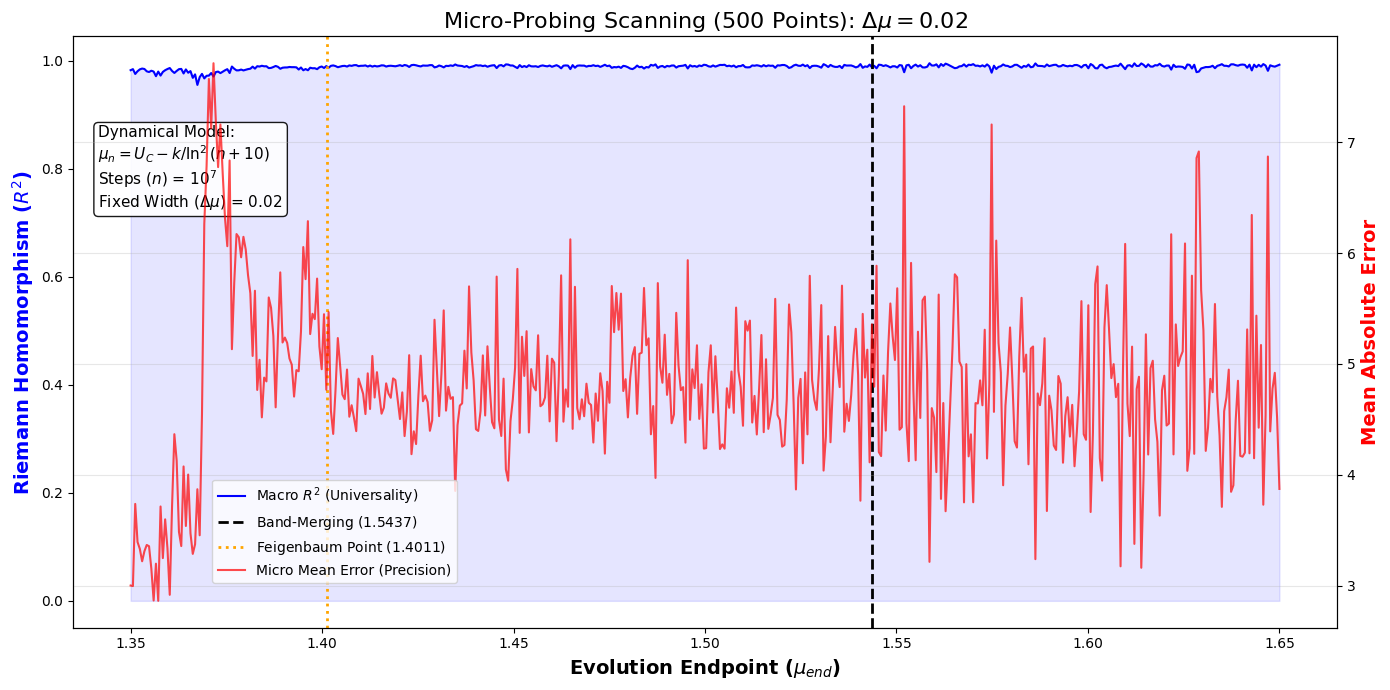

In [1]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigs
from scipy.stats import linregress
import mpmath
import matplotlib.pyplot as plt
import time
from numba import njit

# 真实的黎曼零点
mpmath.mp.dps = 15
N_ZEROS = 100
TRUE_ZEROS = np.array([float(mpmath.zetazero(i).imag) for i in range(1, N_ZEROS + 1)])

@njit
def run_universe_micro_probe(steps, n_bins, u_c, k_opt, c_offset):
    transitions = np.zeros((n_bins, n_bins), dtype=np.uint32)
    x = 0.5
    last_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
    
    for i in range(1, steps + 1):
        # 原汁原味的动力学映射：从左侧缓慢攀升
        # 这里 u_c 相当于公式的渐近线，不是终点
        mu_raw = u_c - k_opt / (np.log(i + c_offset)**2)
        
        # 物理保险丝：防止参数溢出炸毁系统
        if mu_raw < 0.1: 
            mu = 0.1
        elif mu_raw > 2.0:
            mu = 2.0
        else:
            mu = mu_raw
            
        x = 1.0 - mu * x * x
        if x > 1.0: x = 0.999
        elif x < -1.0: x = -0.999
            
        current_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
        transitions[last_bin, current_bin] += 1
        last_bin = current_bin
        
    return transitions

# ================= 🔬 微扰卡尺参数设置区 =================
# 1. 横轴显示真正的结束点 (mu_end_points)
# 设定 500 个探测点，涵盖费根鲍姆点和带合并点
test_points_end = np.linspace(1.35, 1.65, 500)

# 2. 演化物理步数与对数平滑常数
TOTAL_STEPS = 10**7
C_OFFSET = 10.0   

# 3. 极其微小的漂移宽度 (游标卡尺宽度)
# 我们希望在 10^7 步里，mu 只走 0.02 的距离
DELTA_MU = 0.02  

results_R2 = []
results_mean_err = []

print(f"🚀 启动【极高分辨率 500点】微扰参数空间扫描 | 漂移宽度: Δμ = {DELTA_MU}\n")
print(f"{'理论渐近线 U_C':<15} | {'起始 μ (n=1)':<14} | {'结束 μ (n=10^7)':<15} | {'R²':<8} | {'平均误差'}")
print("-" * 75)

start_total_t = time.time()

for idx, mu_end in enumerate(test_points_end):
    # 🎯 核心逆向推导：为了在第 10^7 步刚好到达 mu_end，且总漂移量为 DELTA_MU
    # 推导 k_opt 和 理论渐近线 u_c
    t_start_val = 1.0 / (np.log(1 + C_OFFSET)**2)
    t_end_val   = 1.0 / (np.log(TOTAL_STEPS + C_OFFSET)**2)
    
    # 根据我们要的固定宽度计算出该点需要的比热容 K
    # DELTA_MU = mu_end - mu_start = K * (t_start_val - t_end_val)
    k_opt = DELTA_MU / (t_start_val - t_end_val)
    
    # 根据计算出的 K，算出公式里那个永远达不到的渐近线 U_C
    # mu_end = U_C - K * t_end_val
    u_c = mu_end + k_opt * t_end_val
    
    # 算出起点 (只是为了验证打印)
    mu_start = u_c - k_opt * t_start_val
    
    # 注入原汁原味的演化
    trans = run_universe_micro_probe(TOTAL_STEPS, 5000, u_c, k_opt, C_OFFSET)
    
    P_sparse = sp.csr_matrix(trans, dtype=np.float64)
    row_sums = np.array(P_sparse.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1.0 
    P_sparse.data /= row_sums[P_sparse.indices]
    
    try:
        eigenvalues, _ = eigs(P_sparse, k=N_ZEROS + 20, which='LM', tol=1e-4)
        phases = np.sort(np.angle(eigenvalues[np.abs(eigenvalues.imag) > 1e-4]))
        unwrapped = np.unwrap(phases)
        
        min_len = min(len(unwrapped), N_ZEROS)
        
        if min_len > 10:
            unwrapped_trunc = unwrapped[:min_len]
            true_zeros_trunc = TRUE_ZEROS[:min_len]
            
            slope, intercept, r_val, _, _ = linregress(unwrapped_trunc, true_zeros_trunc)
            pred = slope * unwrapped_trunc + intercept
            err = np.mean(np.abs(pred - true_zeros_trunc))
            r2 = r_val**2
        else:
            err = 20.0 
            r2 = 0.0
            
    except Exception:
        err = 20.0
        r2 = 0.0
        
    results_R2.append(r2)
    results_mean_err.append(err)
    
    # 实时打印：每 50 个点汇报一次
    if (idx + 1) % 50 == 0 or idx == 0:
        print(f"{u_c:<15.6f} | {mu_start:<14.6f} | {mu_end:<15.6f} | {r2:<8.4f} | {err:.4f}")

print("-" * 75)
print(f"✅ 扫描完成！总耗时: {(time.time()-start_total_t)/60:.2f} 分钟")

# ================= 高清绘图环节 =================
fig, ax1 = plt.subplots(figsize=(14, 7))

ax1_twin = ax1.twinx()
# 使用更密集的线条，突出相变边界
ax1.plot(test_points_end, results_R2, 'b-', lw=1.5, label='Macro $R^2$ (Universality)')
ax1.fill_between(test_points_end, results_R2, color='blue', alpha=0.1)
ax1_twin.plot(test_points_end, results_mean_err, 'r-', lw=1.5, alpha=0.7, label='Micro Mean Error (Precision)')

ax1.axvline(1.543689, color='k', linestyle='--', lw=2, label='Band-Merging ($1.5437$)')
ax1.axvline(1.401155, color='orange', linestyle=':', lw=2, label='Feigenbaum Point ($1.4011$)')

ax1.set_xlabel(r'Evolution Endpoint ($\mu_{end}$)', fontsize=14, fontweight='bold')
ax1.set_ylabel(r'Riemann Homomorphism ($R^2$)', color='b', fontsize=14, fontweight='bold')
ax1_twin.set_ylabel('Mean Absolute Error', color='r', fontsize=14, fontweight='bold')
ax1.set_title(f'Micro-Probing Scanning (500 Points): $\Delta\mu = {DELTA_MU}$', fontsize=16)

# 标记文本框解释参数动态
text_str = f"Dynamical Model:\n$\mu_n = U_C - k / \ln^2(n+10)$\nSteps ($n$) = $10^7$\nFixed Width ($\Delta\mu$) = {DELTA_MU}"
ax1.text(0.02, 0.85, text_str, transform=ax1.transAxes, fontsize=11,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

fig.legend(loc='lower left', bbox_to_anchor=(0.15, 0.15), ncol=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()